In [1]:
import os
import re
import csv
from collections import defaultdict
from statistics import mean

def parse_log_file_last_metrics(path):
    """从 log 文件末尾提取最后一次 eval 的指标（支持科学计数法）"""
    eval_metrics = {}
    with open(path, encoding="utf-8") as f:
        lines = f.readlines()

    i = len(lines) - 1
    while i >= 0:
        line = lines[i].strip()
        if line.startswith("start to eval"):
            # hit20
            if i + 1 < len(lines) and lines[i+1].startswith("hit20"):
                m = re.search(r"hit20\s+([0-9.+-eE]+)", lines[i+1])
                if m:
                    eval_metrics["hit20"] = float(m.group(1))
            # hit50
            if i + 2 < len(lines) and lines[i+2].startswith("hit50"):
                m = re.search(r"hit50\s+([0-9.+-eE]+)", lines[i+2])
                if m:
                    eval_metrics["hit50"] = float(m.group(1))
            # hit100
            if i + 3 < len(lines) and lines[i+3].startswith("hit100"):
                m = re.search(r"hit100\s+([0-9.+-eE]+)", lines[i+3])
                if m:
                    eval_metrics["hit100"] = float(m.group(1))
            # 复合指标行
            if i + 4 < len(lines) and lines[i+4].startswith("roc_auc"):
                # 改进的匹配：完整支持科学计数法
                nums = re.findall(r"[-+]?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?", lines[i+4])
                if len(nums) >= 4:
                    fields = ['roc_auc', 'pr_auc', 'f1', 'mrr_pess']
                    result_dict = dict(zip(fields, map(float, nums[-5:])))
                    eval_metrics.update(result_dict)
            if eval_metrics:
                break
        i -= 1
    return eval_metrics


# ==== 用户指定参数 ====
dataset = "fly_larva"
ratios = [0.3, 0.5]
hs = [11, 12, 13, 14, 15]
gammas = [2, 3, 4, 5, 6]
alpha_list = [1, 5, 10, 15, 20, 30, 50, 80]
seeds = [1]  # 可扩展多 seed

log_base_dir = "."
output_dir = "./results"
os.makedirs(output_dir, exist_ok=True)

ALL_METRICS = ['hit20', 'hit50', 'hit100', 'roc_auc', 'pr_auc', 'f1', 'mrr_pess', 'mrr_opt']

# ==== 聚合结果 ====
metric_bucket = defaultdict(list)
metric_keys = set()

for seed in seeds:
    for ratio in ratios:
        for h in hs:
            for gamma in gammas:
                for alpha in alpha_list:
                    fname = f"r{ratio}-h{h}-g{gamma}-a{alpha}.log"
                    log_path = os.path.join(log_base_dir, fname)
                    key = (ratio, h, gamma, alpha)

                    if not os.path.isfile(log_path):
                        print(f"[WARN] 缺失: {log_path}")
                        metrics = {k: 0.0 for k in ALL_METRICS}
                        metric_bucket[key].append(metrics)
                        metric_keys.update(metrics.keys())
                        continue

                    metrics = parse_log_file_last_metrics(log_path)

                    if not metrics:
                        print(f"[WARN] 无 test 指标: {log_path}")
                        metrics = {k: 0.0 for k in ALL_METRICS}

                    metric_bucket[key].append(metrics)
                    metric_keys.update(metrics.keys())


# ==== 写入 CSV ====
csv_path = os.path.join(output_dir, f"{dataset}_grid_result.csv")
metric_keys = sorted(metric_keys)
header = ["split_ratio", "h", "gamma", "alpha"] + metric_keys

with open(csv_path, "w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=header)
    writer.writeheader()
    for key, metrics_list in metric_bucket.items():
        ratio, h, gamma, alpha = key
        row = {"split_ratio": ratio, "h": h, "gamma": gamma, "alpha": alpha}
        for k in metric_keys:
            vals = [m[k] for m in metrics_list if k in m]
            if vals:
                mu = round(round(mean(vals), 4) * 100, 2)
                row[k] = f"{mu}"
            else:
                row[k] = "0.0"
        writer.writerow(row)

print(f"[INFO] 写入完毕: {csv_path}")


[INFO] 写入完毕: ./results/fly_larva_grid_result.csv


========= 帕累托最优参数 (ratio=0.9) =========
ID 1: (h=14.0, gamma=4.0, alpha=5.0) roc_auc=87.460, pr_auc=55.170, f1=55.820
ID 2: (h=13.0, gamma=5.0, alpha=10.0) roc_auc=87.400, pr_auc=56.140, f1=56.760
ID 3: (h=15.0, gamma=4.0, alpha=20.0) roc_auc=86.670, pr_auc=55.580, f1=56.890


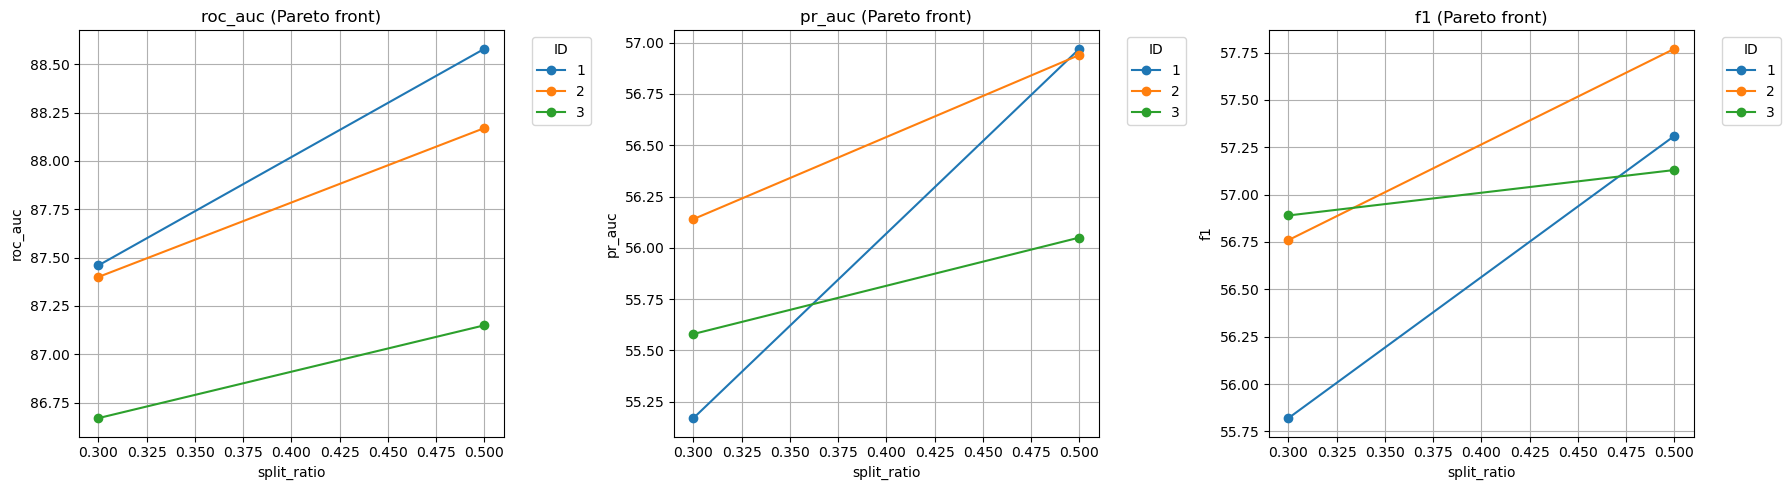


========= 帕累托最优编号对应表 =========
ID 1: (h=14.0, gamma=4.0, alpha=5.0)
ID 2: (h=13.0, gamma=5.0, alpha=10.0)
ID 3: (h=15.0, gamma=4.0, alpha=20.0)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# === 读取 CSV 结果 ===
csv_path = f"./results/{dataset}_grid_result.csv"
df = pd.read_csv(csv_path)
for col in ["roc_auc", "pr_auc", "f1"]:
    df[col] = df[col].astype(float)

# === 选取 ratio = 0.3 的结果 ===
df_final = df[df["split_ratio"] == 0.3].copy()

# === 帕累托最优集判断函数 ===
def is_pareto_efficient(costs):
    """
    输入: ndarray [n, m]，每行是一个样本（m维指标）
    输出: bool 数组，True 表示该点是帕累托最优
    """
    import numpy as np
    costs = np.array(costs)
    n_points = costs.shape[0]
    is_efficient = np.ones(n_points, dtype=bool)
    for i in range(n_points):
        if is_efficient[i]:
            # 任何同时 >= 且至少有一个 > 的点会被 dominated
            dominated = np.all(costs <= costs[i], axis=1) & np.any(costs < costs[i], axis=1)
            is_efficient[dominated] = False
    return is_efficient

# === 计算帕累托最优组合 ===
costs = df_final[["roc_auc", "pr_auc", "f1"]].values
efficient_mask = is_pareto_efficient(costs)
pareto_df = df_final[efficient_mask].sort_values(["roc_auc", "pr_auc", "f1"], ascending=False).reset_index(drop=True)

# === 输出帕累托最优参数 ===
print("========= 帕累托最优参数 (ratio=0.9) =========")
for i, row in pareto_df.iterrows():
    print(f"ID {i+1}: (h={row.h}, gamma={row.gamma}, alpha={row.alpha}) "
          f"roc_auc={row.roc_auc:.3f}, pr_auc={row.pr_auc:.3f}, f1={row.f1:.3f}")

# === 绘图准备 ===
metrics = ["roc_auc", "pr_auc", "f1"]
ratios = sorted(df["split_ratio"].unique())

# 只保留帕累托最优组合的完整曲线
df_pareto = df[df.apply(lambda r: (r["h"], r["gamma"], r["alpha"]) in 
                        [(x.h, x.gamma, x.alpha) for _, x in pareto_df.iterrows()], axis=1)]

# === 绘图 ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for idx_metric, metric in enumerate(metrics):
    ax = axes[idx_metric]
    for i, (_, row) in enumerate(pareto_df.iterrows(), start=1):
        subdf = df_pareto[
            (df_pareto["h"] == row.h) &
            (df_pareto["gamma"] == row.gamma) &
            (df_pareto["alpha"] == row.alpha)
        ].sort_values("split_ratio")

        ax.plot(
            subdf["split_ratio"],
            subdf[metric],
            marker="o",
            label=f"{i}"
        )

    ax.set_title(f"{metric} (Pareto front)")
    ax.set_xlabel("split_ratio")
    ax.set_ylabel(metric)
    ax.grid(True)
    ax.legend(title="ID", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# === 打印编号对应表 ===
print("\n========= 帕累托最优编号对应表 =========")
for i, row in pareto_df.iterrows():
    print(f"ID {i+1}: (h={row.h}, gamma={row.gamma}, alpha={row.alpha})")
